Librerias y funciones necesarias:

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler

In [5]:
def Aplicar_modelo(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    matriz_confusion = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues", xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
    plt.title("Matriz de confusión", fontsize = 12, color = "red")
    plt.xlabel("Predicción", fontweight = "black")
    plt.ylabel("Valor Real", fontweight = "black")
    plt.show()
    
    print(f'Accuracy: {round(accuracy, 2)} \nF1: {round(f1, 2)} \nRecall: {round(recall, 2)} \nPrecision: {round(precision, 2)}')

Importación del dataset

In [7]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

Breve revisión general de los datos que contiene el dataset

In [9]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [10]:
data.shape

(5110, 12)

In [11]:
data.isnull().sum() #Valores nulos

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [12]:
(data.isnull().sum()/data.shape[0]*100).round(2) #Porcentaje de valores nulos

id                   0.00
gender               0.00
age                  0.00
hypertension         0.00
heart_disease        0.00
ever_married         0.00
work_type            0.00
Residence_type       0.00
avg_glucose_level    0.00
bmi                  3.93
smoking_status       0.00
stroke               0.00
dtype: float64

In [13]:
data.dtypes #Tipo de datos en cada variable

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [14]:
data["id"].duplicated().sum() #Duplicados en la columna id que representarian instancias duplicadas

0

## Análisis de variables

#### Género

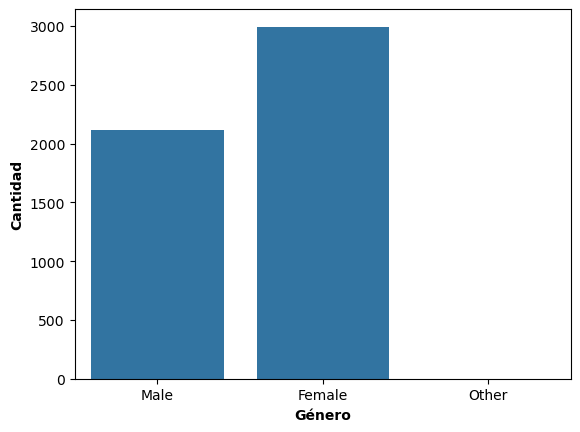

In [17]:
sns.countplot(x = data.gender)
plt.xlabel("Género", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.show()

In [18]:
data[data.gender == "Other"]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


Como hay una sola instancia que posee el valor "Other" en el género, y no sabemos exactamente a qué estaría haciendo referencia, lo valor a eliminar para no utilizar datos dudosos.

In [20]:
indx = data[data.gender == "Other"].index
data.drop(index = indx, inplace = True)

#### Variables binarias (Yes/No | 1/0)

In [22]:
binarias = ["hypertension", "heart_disease", "ever_married"]

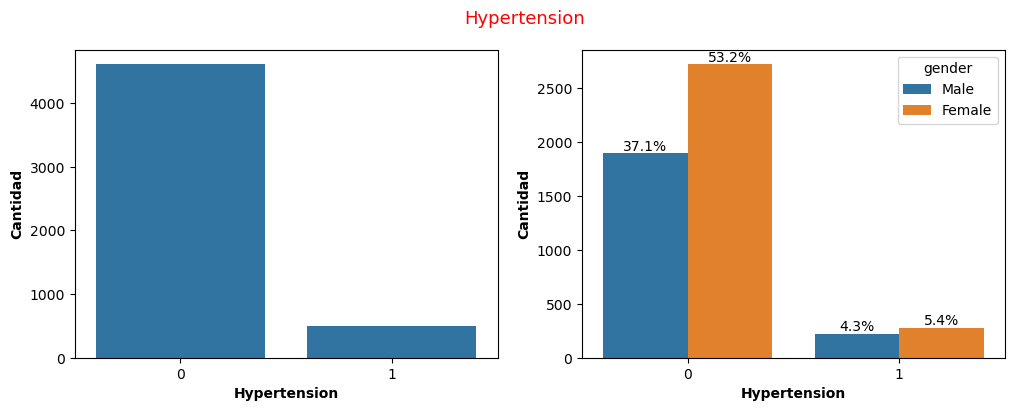

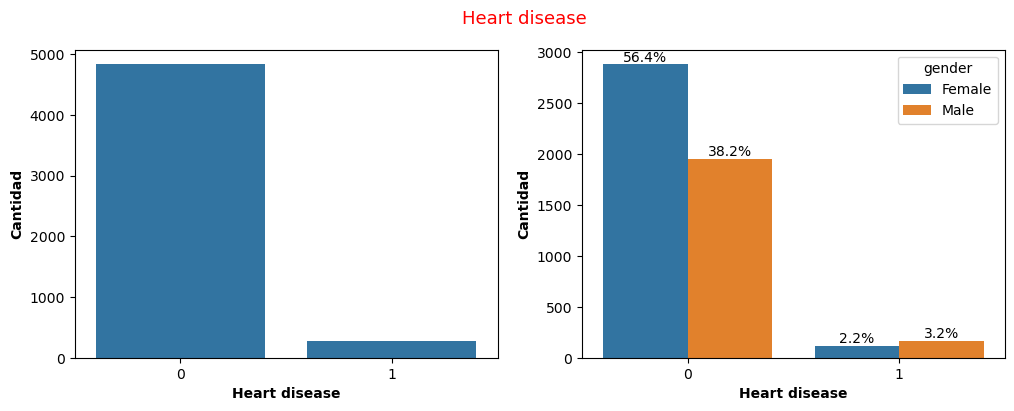

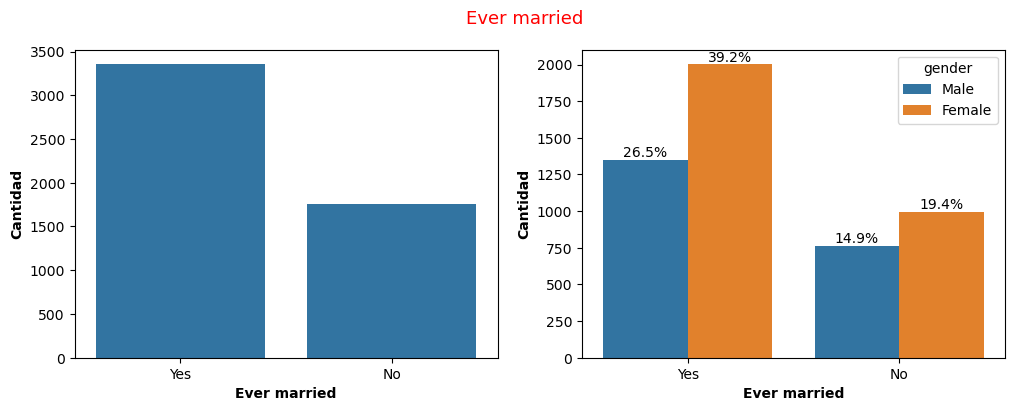

In [23]:
for i in binarias:
    plt.figure(figsize = (12, 4))
    plt.suptitle(i.capitalize().replace("_", " "), fontsize = 13, color = "red")
    
    plt.subplot(1, 2, 1)
    sns.countplot(x = data[i])
    plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    
    plt.subplot(1, 2, 2)
    ax = sns.countplot(x = data[i], hue = data.gender)
    total = data[i].count()
    for c in ax.containers:
        ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')
    plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    
    plt.show()

#### Variables categóricas

In [25]:
categoricas = ["work_type", "Residence_type", "smoking_status"]

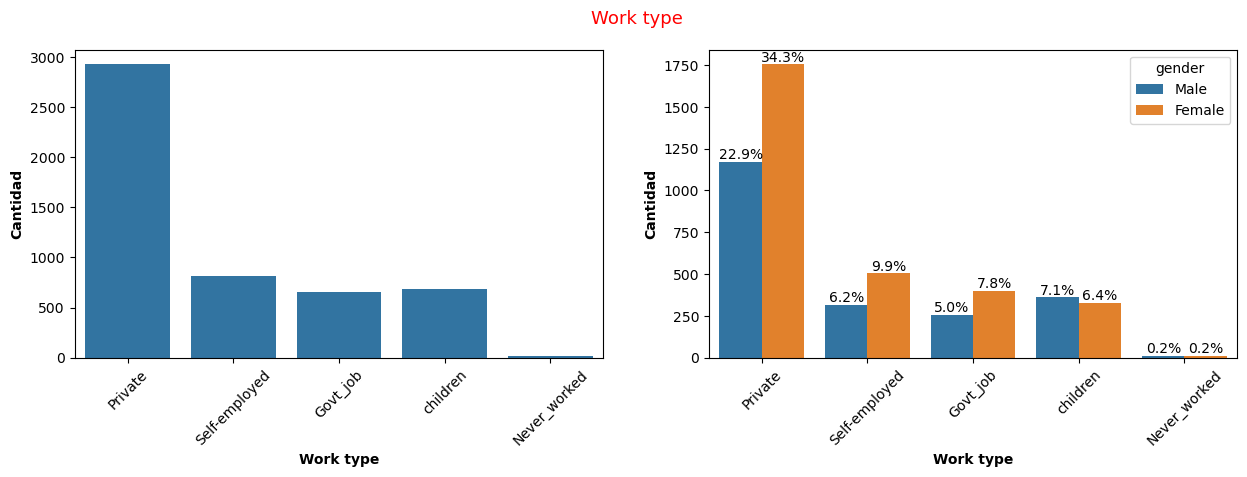

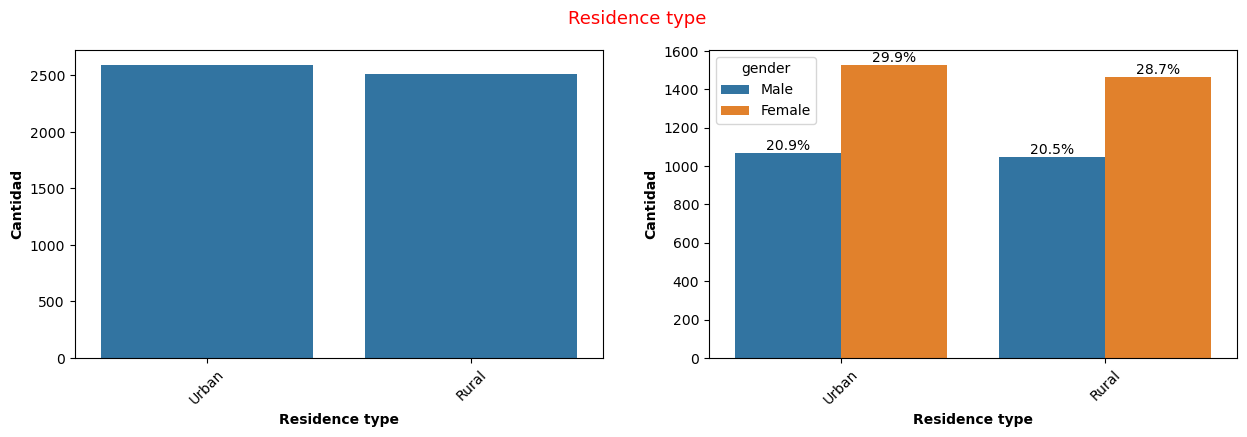

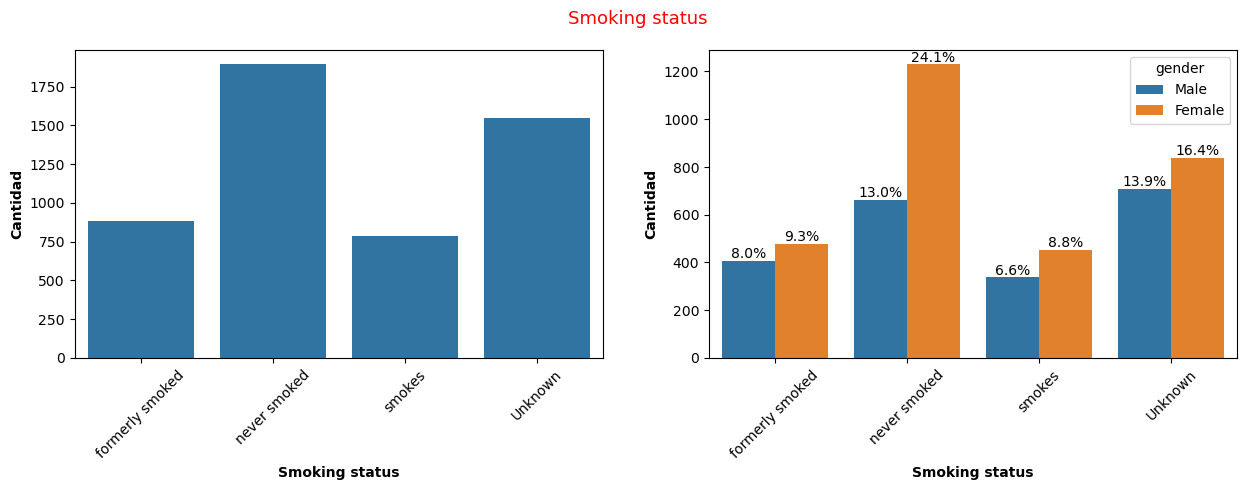

In [26]:
for i in categoricas:
    plt.figure(figsize = (15, 4))
    plt.suptitle(i.capitalize().replace("_", " "), fontsize = 13, color = "red")
    
    plt.subplot(1, 2, 1)
    sns.countplot(x = data[i])
    plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    plt.xticks(rotation = 45)
    
    plt.subplot(1, 2, 2)
    ax = sns.countplot(x = data[i], hue = data.gender)
    total = data[i].count()
    for c in ax.containers:
        ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')
    plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    plt.xticks(rotation = 45)
    
    plt.show()

#### Variables numéricas

In [28]:
numericas = ["age", "avg_glucose_level", "bmi"]

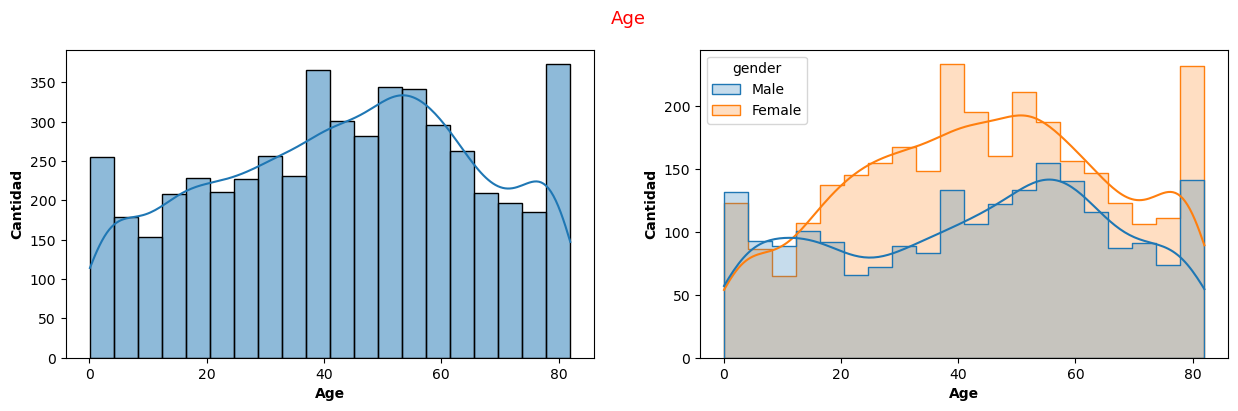

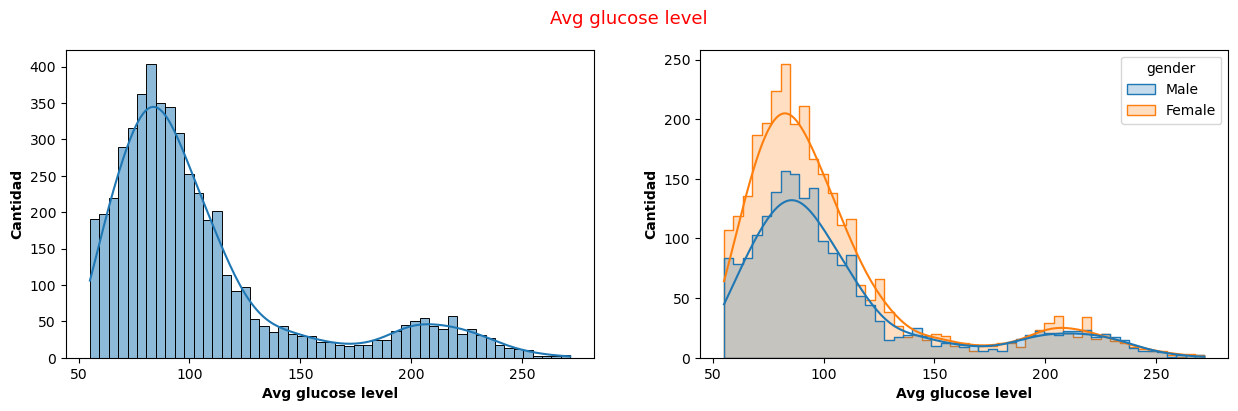

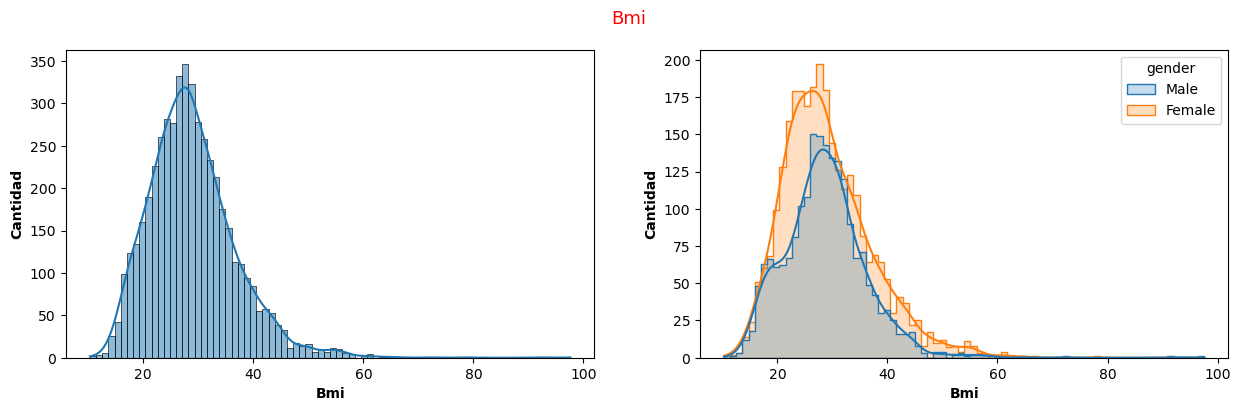

In [29]:
for i in numericas:
    plt.figure(figsize = (15, 4))
    plt.suptitle(i.capitalize().replace("_", " "), fontsize = 13, color = "red")
    plt.subplot(1, 2, 1)
    sns.histplot(data[i], kde = True)
    plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    plt.subplot(1, 2, 2)
    sns.histplot(data = data, x = i, hue = "gender", element = "step", kde = True)
    plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    plt.show()

In [30]:
for i in numericas:
    media = data[i].mean()
    moda = data[i].mode()[0]
    resumen = data.groupby("gender")[i].agg(
                    media = "mean",
                    moda = lambda x: x.mode().mean(),
                    max = "max", 
                    min = "min")
    print(f"\n {i.upper()} | Media: {media.round(2)}, Moda: {moda}")
    print(resumen)


 AGE | Media: 43.23, Moda: 78.0
            media  moda   max   min
gender                             
Female  43.757395  45.0  82.0  0.08
Male    42.483385  57.0  82.0  0.08

 AVG_GLUCOSE_LEVEL | Media: 106.14, Moda: 93.88
             media       moda     max    min
gender                                      
Female  104.057809  73.000000  267.76  55.12
Male    109.088520  89.253125  271.74  55.22

 BMI | Media: 28.89, Moda: 28.7
            media  moda   max   min
gender                             
Female  29.065758  23.4  78.0  10.3
Male    28.647936  26.7  97.6  11.5


#### Grupos según BMI

In [32]:
condiciones = [
    data[data.age >= 20].bmi < 18.5,
    (data[data.age >= 20].bmi >= 18.5) & (data[data.age >= 20].bmi < 25),
    (data[data.age >= 20].bmi >= 25) & (data[data.age >= 20].bmi < 30),
    data[data.age >= 20].bmi >= 30
]

valores = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]

bmi_clasif = np.select(condiciones, valores)

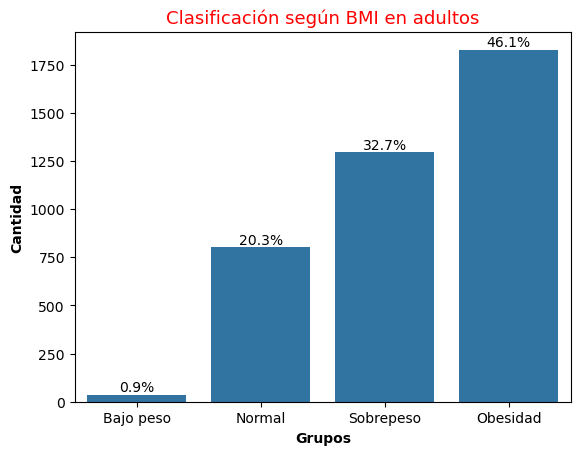

In [33]:
ax = sns.countplot(x = bmi_clasif[bmi_clasif != "0"], order = valores)
total = len(bmi_clasif[bmi_clasif != "0"])
for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')
plt.title("Clasificación según BMI en adultos", fontsize = 13, color = "red")
plt.xlabel("Grupos", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.show()

#### Grupos según niveles de glucosa

In [35]:
condiciones = [
    data[data.age >= 20].avg_glucose_level < 100,
    (data[data.age >= 20].avg_glucose_level >= 100) & (data[data.age >= 20].avg_glucose_level < 126),
    data[data.age >= 20].avg_glucose_level >= 126
]

valores = ["Normal", "Prediabetes", "Diabetes"]

glucose_clasif = np.select(condiciones, valores)

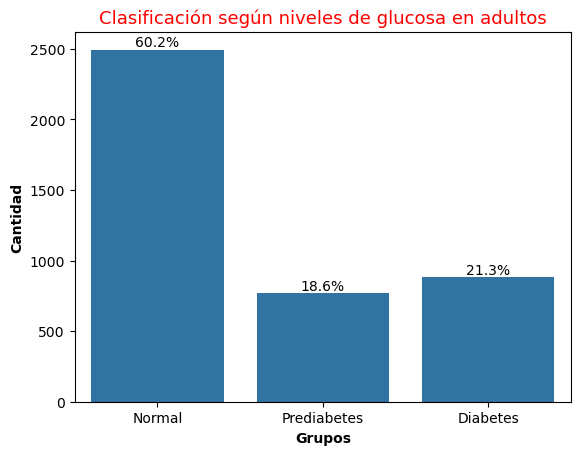

In [36]:
ax = sns.countplot(x = glucose_clasif, order = valores)
total = len(glucose_clasif)
for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')
plt.title("Clasificación según niveles de glucosa en adultos", fontsize = 13, color = "red")
plt.xlabel("Grupos", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.show()

### Outliers

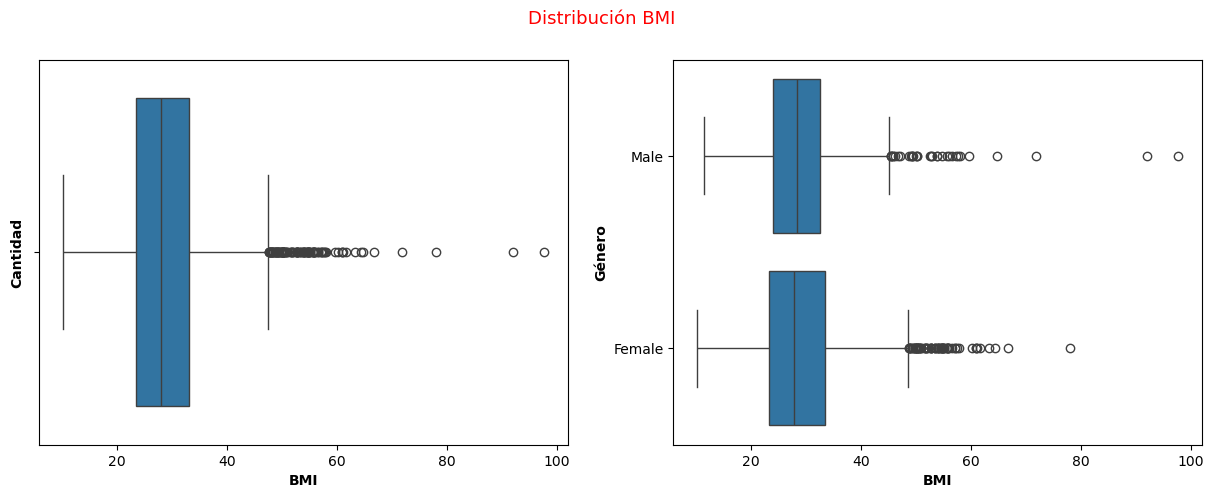

In [38]:
plt.figure(figsize = (15, 5))
plt.suptitle("Distribución BMI", fontsize = 13, color = "red")
plt.subplot(1, 2, 1)
sns.boxplot(data = data, x = "bmi")
plt.xlabel("BMI", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.subplot(1, 2, 2)
sns.boxplot(data = data, x = "bmi", y = "gender")
plt.xlabel("BMI", fontweight = "black")
plt.ylabel("Género", fontweight = "black")
plt.show()

Un BMI superior a 30 ya es considerado obesidad, por lo que se va a considerar como outliers los valores extremadamente altos de BMI, y se utilizará el método del rango intercuartílico para identificar los límites.

In [40]:
Q3 = data["bmi"].quantile(0.75)
Q1 = data["bmi"].quantile(0.25)
iqr = Q3 - Q1

upper = Q3 + (3 * iqr)

outliers = data[data["bmi"] > upper]
outliers

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
358,66333,Male,52.0,0,0,Yes,Self-employed,Urban,78.40,64.8,never smoked,0
544,545,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0
928,41097,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0
1559,37759,Female,53.0,0,0,Yes,Private,Rural,72.63,66.8,Unknown,0
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
2764,20292,Female,24.0,0,0,Yes,Private,Urban,85.55,63.3,never smoked,0
4188,70670,Female,27.0,0,0,Yes,Private,Rural,57.96,64.4,never smoked,0
4209,51856,Male,38.0,1,0,Yes,Private,Rural,56.90,92.0,never smoked,0


In [41]:
data.drop(index = outliers.index, inplace = True)

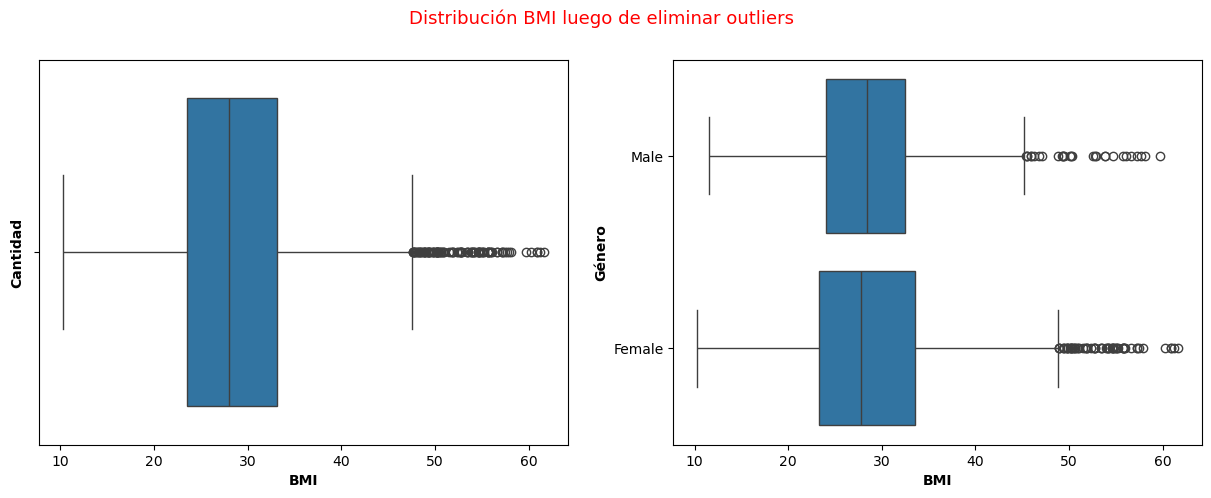

In [42]:
plt.figure(figsize = (15, 5))
plt.suptitle("Distribución BMI luego de eliminar outliers", fontsize = 13, color = "red")
plt.subplot(1, 2, 1)
sns.boxplot(data = data, x = "bmi")
plt.xlabel("BMI", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.subplot(1, 2, 2)
sns.boxplot(data = data, x = "bmi", y = "gender")
plt.xlabel("BMI", fontweight = "black")
plt.ylabel("Género", fontweight = "black")
plt.show()

### Datos faltantes

In [44]:
media = data["bmi"].mean()
moda = data["bmi"].mode()[0]
resumen = data.groupby("gender")["bmi"].agg(
                    media = "mean",
                    moda = lambda x: x.mode().mean(),
                    max = "max", 
                    min = "min")
print(f"\n BMI | Media: {media.round(2)}, Moda: {moda}")
print(resumen)


 BMI | Media: 28.82, Moda: 28.7
            media  moda   max   min
gender                             
Female  29.011753  23.4  61.6  10.3
Male    28.542451  26.7  59.7  11.5


Ya que es una variable con una distribución asimétrica y que la media se ve afectada por los valores extremos altos, se va a completar los datos faltantes con la moda correspondiente a cada género.

In [46]:
moda_f = data[data.gender == "Female"].bmi.mode().mean()
moda_m = data[data.gender == "Male"].bmi.mode().mean()

data["bmi"] = data.bmi.fillna(data.gender.apply(lambda x: moda_f if x == "Female" else moda_m))

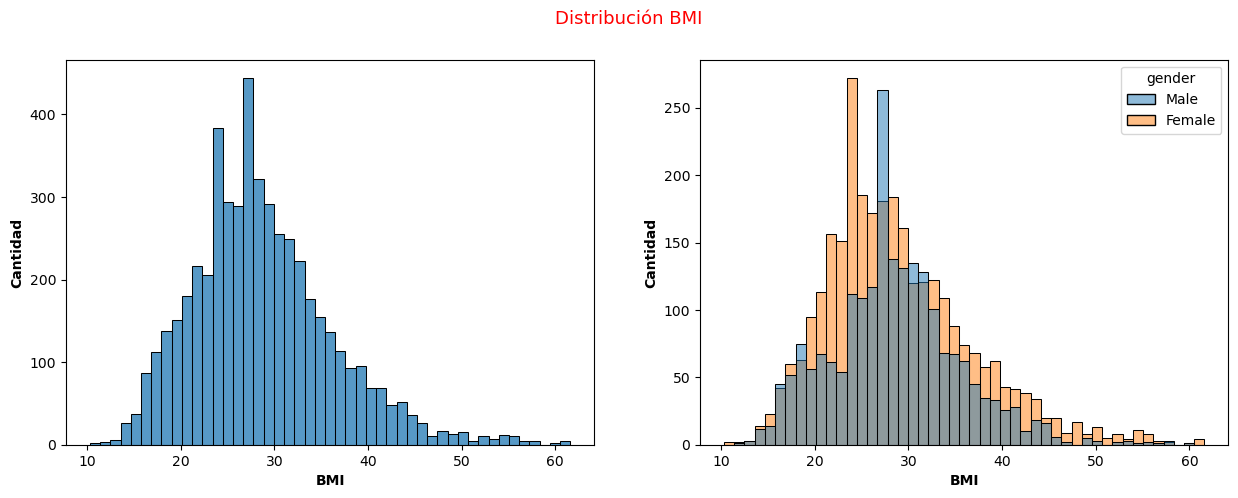

In [47]:
plt.figure(figsize = (15, 5))
plt.suptitle("Distribución BMI", fontsize = 13, color = "red")
plt.subplot(1, 2, 1)
sns.histplot(data = data, x = "bmi")
plt.xlabel("BMI", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.subplot(1, 2, 2)
sns.histplot(data = data, x = "bmi", hue = "gender")
plt.xlabel("BMI", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.show()

### Variables categoricas/binarias a numericas

In [49]:
data.replace(
    to_replace = {"gender": {"Male": 0, "Female": 1}, 
                  "ever_married": {"No": 0, "Yes": 1}, 
                  "Residence_type": {"Rural": 0, "Urban": 1}}, 
    inplace = True)

C:\Users\marie\AppData\Local\Temp\ipykernel_20692\3877749178.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(


### Correlaciones

In [51]:
variables_num = data.columns.drop(["id", "work_type", "smoking_status", "stroke"])
variables_num

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi'],
      dtype='object')

<Axes: >

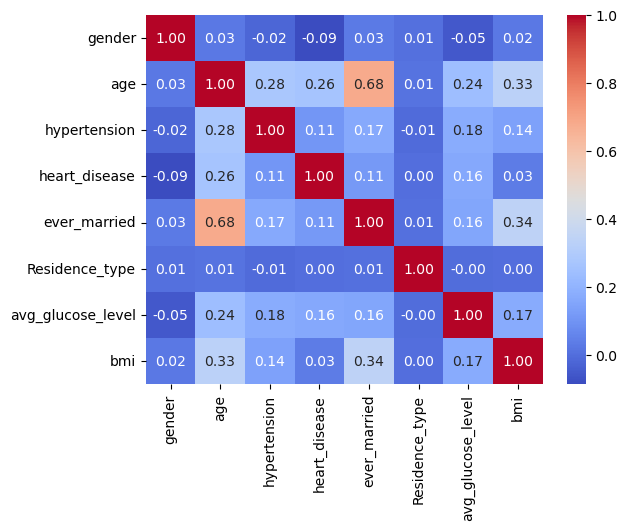

In [52]:
corr_matrix = data[variables_num].corr()
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")

Se puede ver una relación considerable entre age y ever_married, lo cual es esperable ya que es muy probable que a mayor edad aumente la probabilidad de haberse casado.

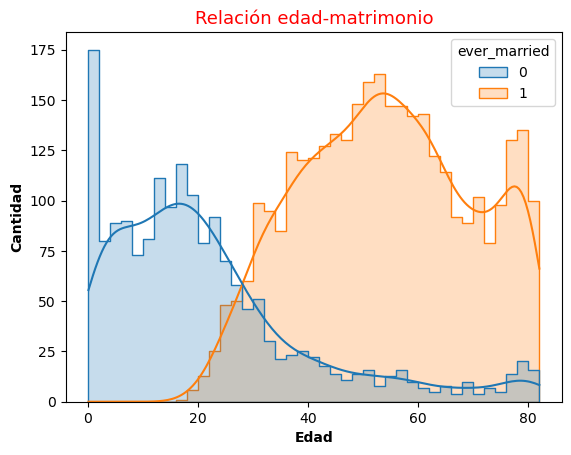

In [54]:
plt.title("Relación edad-matrimonio", fontsize = 13, color = "red")
sns.histplot(x = data.age, hue = data.ever_married, element = "step", kde = True, binwidth = 2)
plt.xlabel("Edad", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.show()

### Variable objetivo

Representación de cada grupo objetivo (0 y 1)

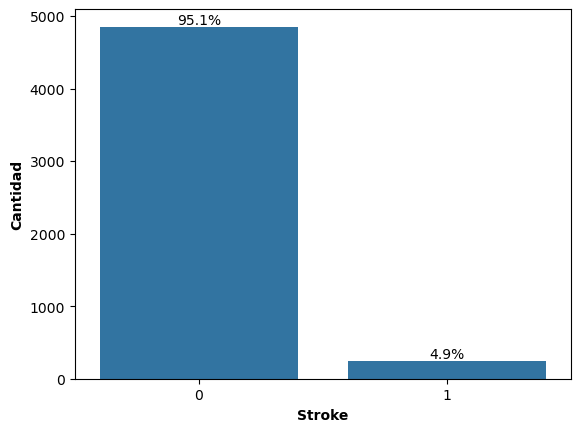

In [57]:
ax = sns.countplot(x = data.stroke)
total = len(data)
for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')
plt.xlabel("Stroke", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.show()

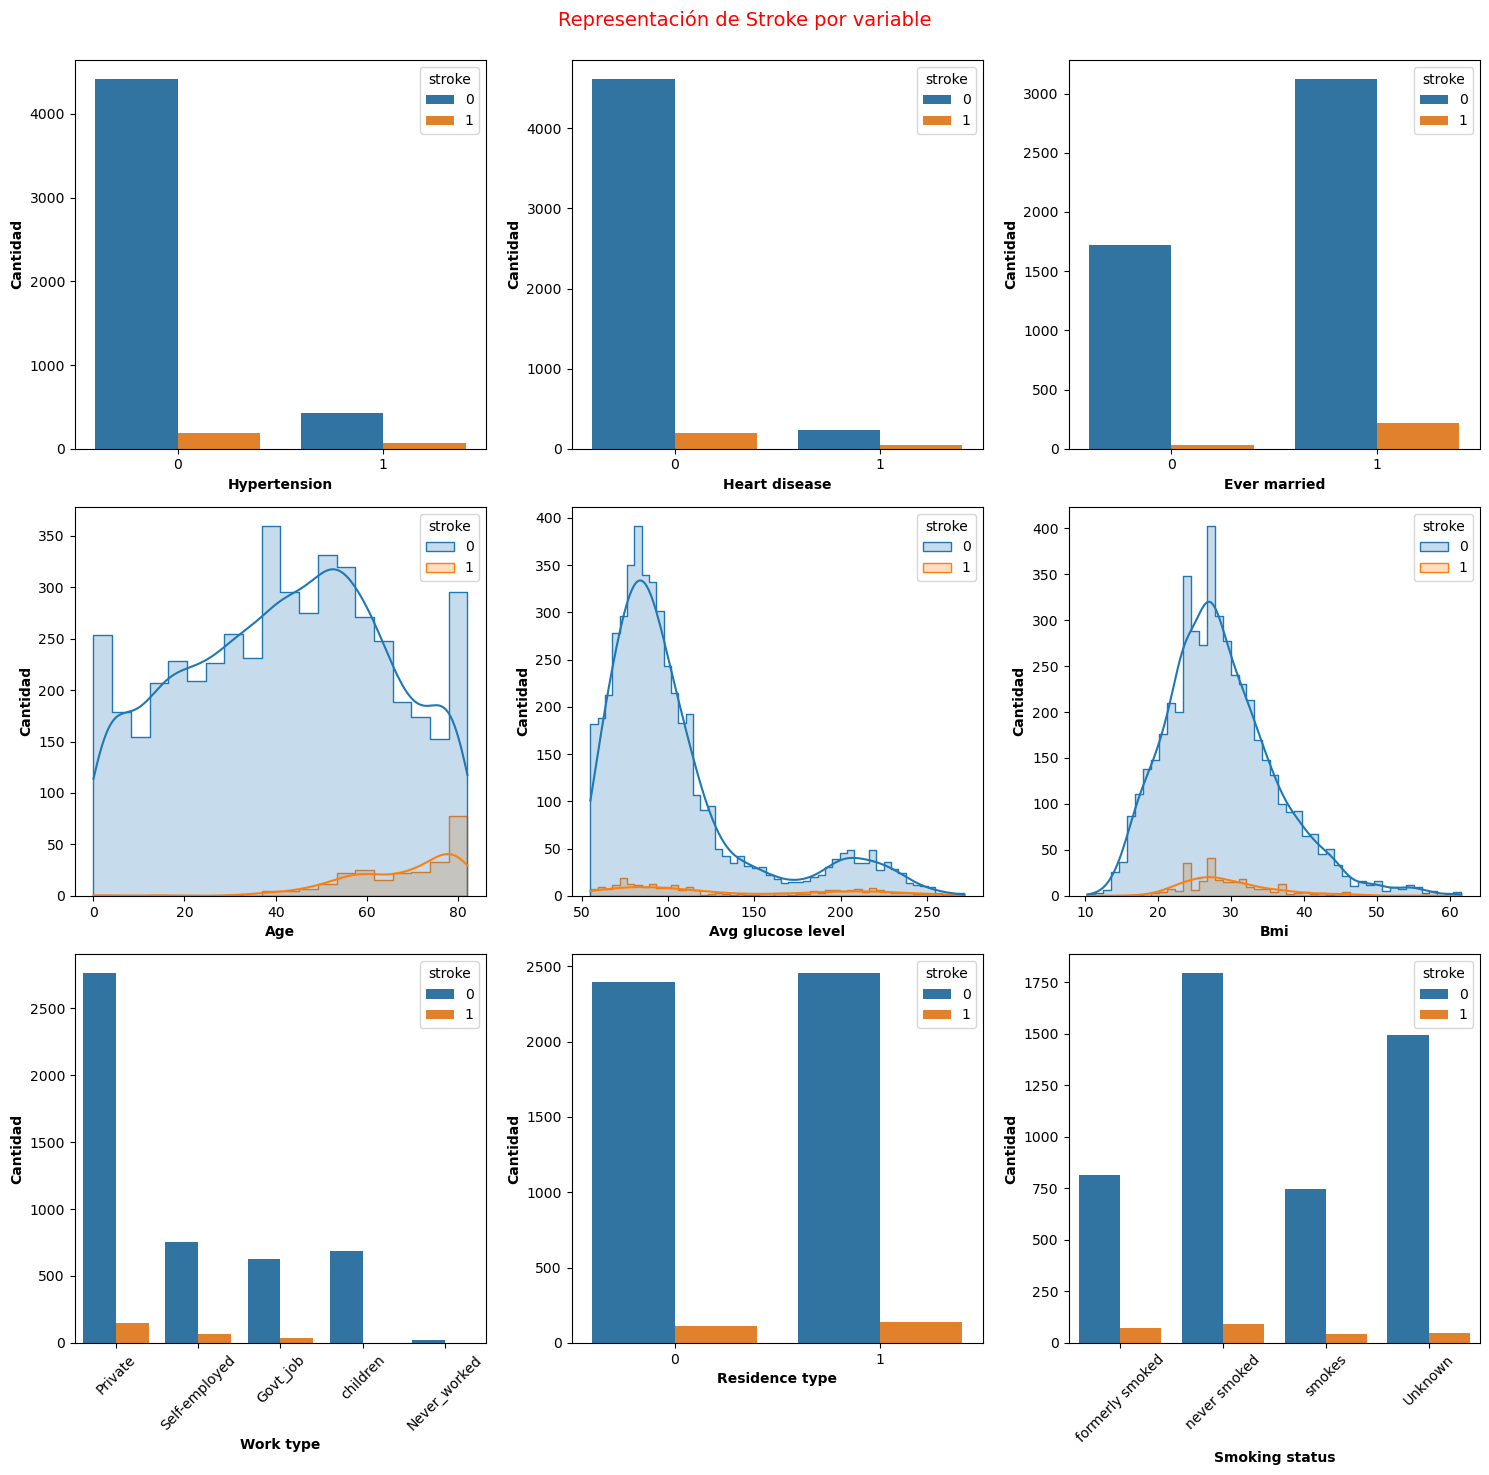

In [58]:
plt.figure(figsize = (15, 15))
plt.suptitle("Representación de Stroke por variable", fontsize = 14, color = "red")
for indx, i in enumerate(binarias+numericas+categoricas, start = 1):
    plt.subplot(3, 3, indx)
    if i in numericas:
        sns.histplot(x = data[i], hue = data.stroke, element = "step", kde = True)
        plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
        plt.ylabel("Cantidad", fontweight = "black")
    else:
        sns.countplot(x = data[i], hue = data.stroke)
        plt.xlabel(i.capitalize().replace("_", " "), fontweight = "black")
        plt.ylabel("Cantidad", fontweight = "black")
        if data[i].dtype == object:
            plt.xticks(rotation = 45)

plt.tight_layout(rect=[0, 0, 1, 0.98]) 
plt.show()

In [59]:
variables = data.columns.drop(["id", "work_type", "smoking_status"])
corr_vector = data[variables].corr()["stroke":]

<Axes: title={'center': 'Correlación entre Stroke y las variables'}>

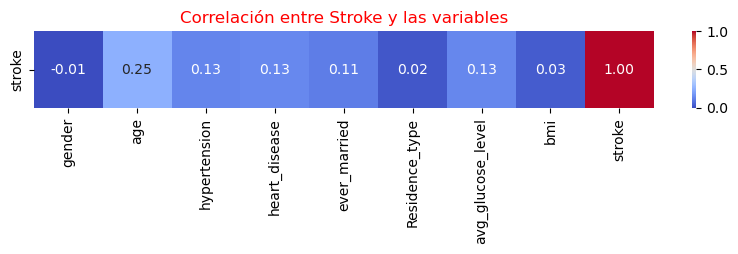

In [60]:
plt.figure(figsize = (10, 1))
plt.title("Correlación entre Stroke y las variables", fontsize = 12, color = "red")
sns.heatmap(corr_vector, annot = True, cmap = "coolwarm", fmt = ".2f")

No hay una fuerte correlación con ninguna de la variables. La variable que muetra algo de correlación es la edad, pero no es muy alta.

### Tratamiento de variables categóricas (dummies)

In [63]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,51676,1,61.0,0,0,1,Self-employed,0,202.21,23.4,never smoked,1
2,31112,0,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1
3,60182,1,49.0,0,0,1,Private,1,171.23,34.4,smokes,1
4,1665,1,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1


In [64]:
data = pd.get_dummies(data, columns = ["work_type", "smoking_status"])

In [65]:
data.head(2)

,id,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,0,67.0,0,1,1,1,228.69,36.6,1,False,False,True,False,False,False,True,False,False
1,51676,1,61.0,0,0,1,0,202.21,23.4,1,False,False,False,True,False,False,False,True,False


In [66]:
data.drop(columns = ["id", "work_type_Never_worked", "smoking_status_Unknown"], inplace = True)

### División en Train y Test

In [68]:
X = data.drop(columns = "stroke").copy()
y = data["stroke"].copy()

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.75, test_size = 0.25, random_state = 7)

In [70]:
X_train.shape

(3825, 15)

In [71]:
X_test.shape

(1276, 15)

In [72]:
y_train.value_counts()

stroke
0    3638
1     187
Name: count, dtype: int64

In [73]:
y_test.value_counts()

stroke
0    1214
1      62
Name: count, dtype: int64

### Balanceo de la variable objetivo

Como la variable objetivo positiva se encuentra tan poco representada (solo un 5% de las instancias son positivas para derrame cerebral) se va a aplicar SMOTENC para crear datos ficticios que la balanceen en el conjunto de datos para entrenamiento.

In [76]:
cat_features = [i for i, col in enumerate(X_train.columns) if any(c in col for c in X_train.columns.drop(["age", "avg_glucose_level", "bmi"]))]
sm = SMOTENC(categorical_features = cat_features, random_state = 7)
X_train_b, y_train_b = sm.fit_resample(X_train, y_train)

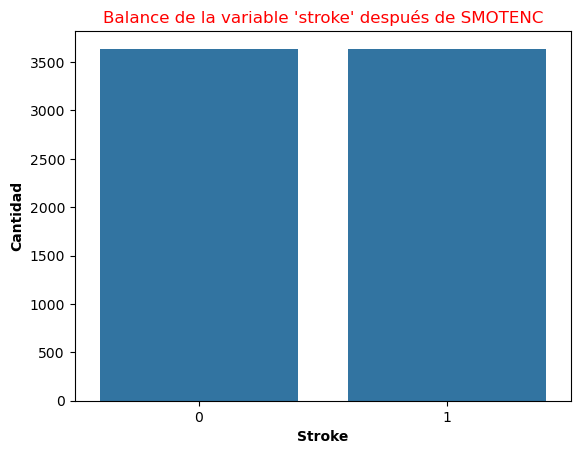

In [77]:
sns.countplot(x = y_train_b)
plt.title("Balance de la variable 'stroke' después de SMOTENC", fontsize = 12, color = "red")
plt.xlabel("Stroke", fontweight = "black")
plt.ylabel("Cantidad", fontweight = "black")
plt.show()

## Escalado de variables numéricas

In [79]:
X_train_b_scaled = X_train_b.copy()
X_test_scaled = X_test.copy()

In [80]:
X_train_array = X_train_b.values
X_test_array = X_test.values

In [81]:
num_features = [i for i in range(X_train_b.shape[1]) if i not in cat_features]

In [82]:
scaler = StandardScaler()

In [83]:
X_train_b_scaled.iloc[:, num_features] = scaler.fit_transform(X_train_array[:, num_features])
X_test_scaled.iloc[:, num_features] = scaler.transform(X_test_array[:, num_features])

In [84]:
X_train_b_scaled.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,-1.022757,1,0,0,0,-0.380432,-0.864820,False,True,False,False,False,False,True
1,1,-1.526525,0,0,0,1,0.208071,-1.075769,False,True,False,False,False,True,False
2,0,-0.290003,0,0,1,1,1.634835,2.209008,False,True,False,False,False,False,False
3,0,-0.747974,0,0,1,1,0.830286,0.702230,False,True,False,False,False,False,False
4,0,-0.015220,0,0,1,1,-0.907494,-0.322380,False,True,False,False,False,True,False


In [85]:
X_test_scaled.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1561,0,0.305360,1,1,1,1,0.092255,0.852908,False,True,False,False,True,False,False
474,1,-1.068554,0,0,0,1,-0.809440,-0.925091,False,True,False,False,False,False,True
2365,1,-0.885365,0,0,0,1,1.778018,0.807704,False,True,False,False,False,False,False
4517,1,-1.251742,0,0,0,1,-1.022585,1.214534,False,True,False,False,False,False,False
3554,1,-0.473191,0,0,1,0,-0.568928,-1.151108,False,True,False,False,False,True,False


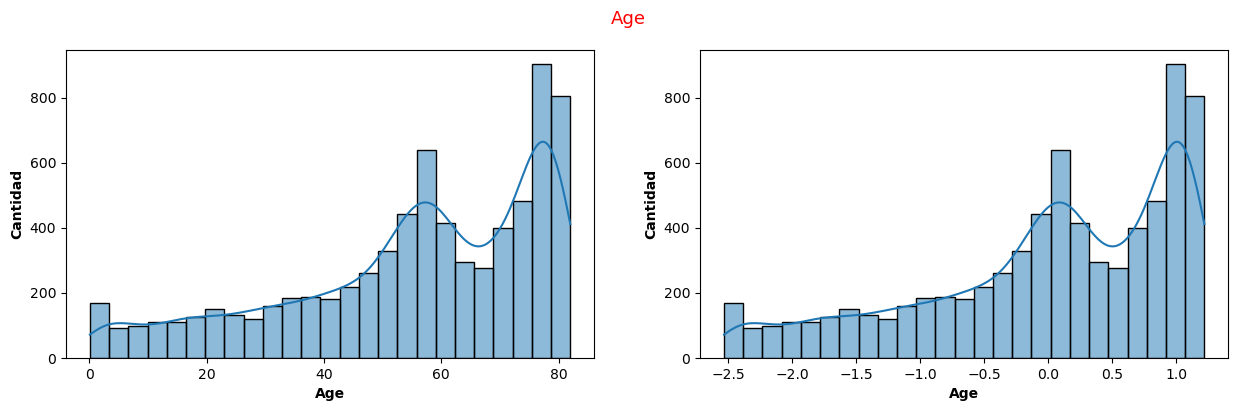

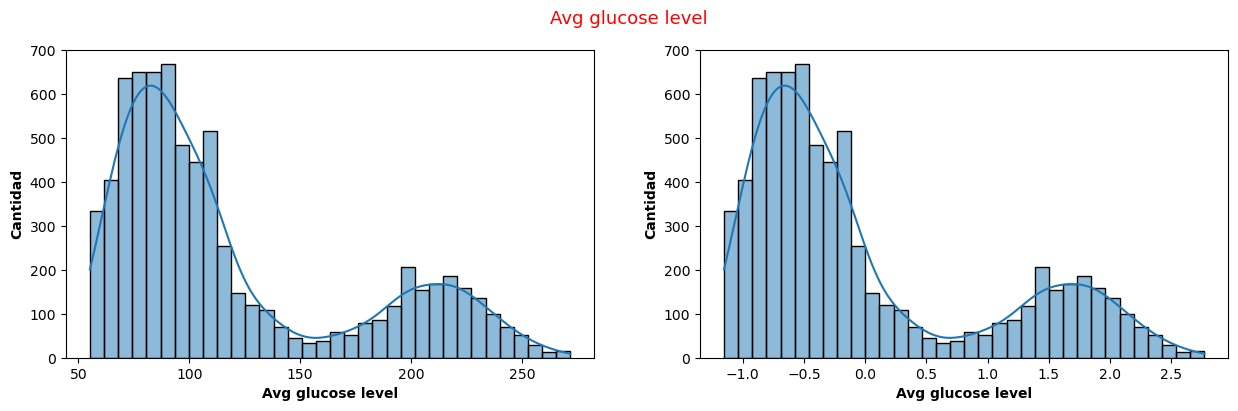

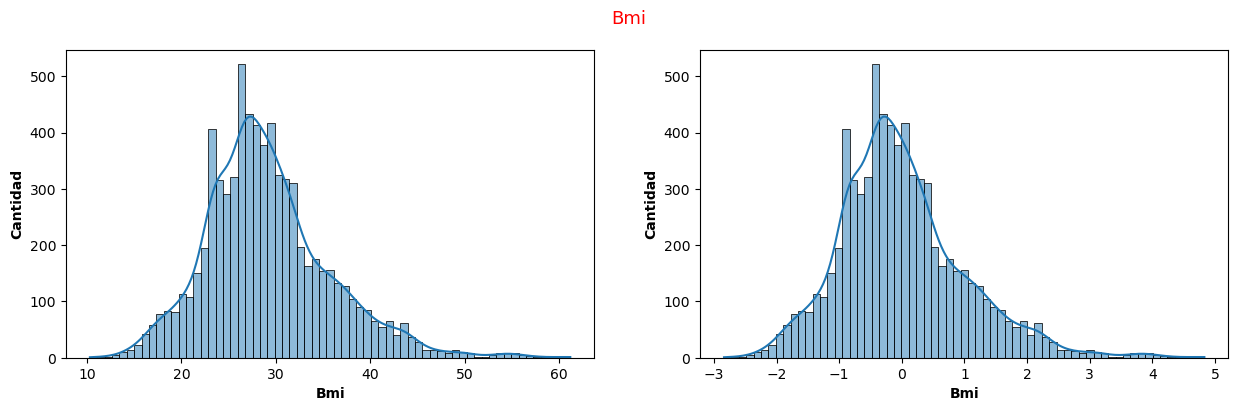

In [86]:
for i in num_features:
    plt.figure(figsize = (15, 4))
    plt.suptitle(X_train_b.columns[i].capitalize().replace("_", " "), fontsize = 13, color = "red")
    plt.subplot(1, 2, 1)
    sns.histplot(X_train_b.iloc[:,i], kde = True)
    plt.xlabel(X_train_b_scaled.columns[i].capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    plt.subplot(1, 2, 2)
    sns.histplot(data = X_train_b_scaled, x = X_train_b_scaled.columns[i], kde = True)
    plt.xlabel(X_train_b_scaled.columns[i].capitalize().replace("_", " "), fontweight = "black")
    plt.ylabel("Cantidad", fontweight = "black")
    plt.show()

## Benchmark: Regresión logística

Se eligió como modelo base una regresión logística

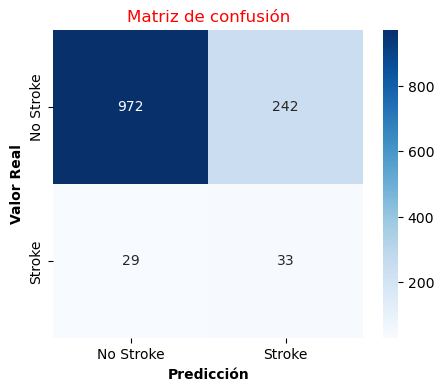

Accuracy: 0.79 
F1: 0.2 
Recall: 0.53 
Precision: 0.12


In [89]:
modelo_lr = LogisticRegression(max_iter = 100000, random_state = 56)
Aplicar_modelo(model = modelo_lr, X_train = X_train_b_scaled, y_train = y_train_b, X_test = X_test_scaled, y_test = y_test)

### KNN

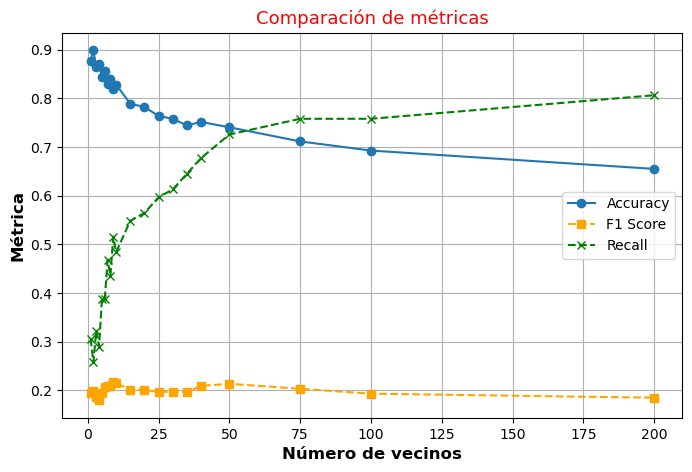

In [91]:
accuracy_list = []
f1_list = []
recall_list = []
k_vecinos = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,50,75,100,200]

for k in k_vecinos:
    modelo = KNeighborsClassifier(n_neighbors = k)
    modelo.fit(X_train_b_scaled, y_train_b)
    y_pred = modelo.predict(X_test_scaled)
    matriz_confusion = confusion_matrix(y_test, y_pred)
    accuracy_list.append(accuracy_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

plt.figure(figsize=(8, 5))          
plt.plot(k_vecinos, accuracy_list, 'o-', label='Accuracy')
plt.plot(k_vecinos, f1_list, 's--', label='F1 Score', color='orange')
plt.plot(k_vecinos, recall_list, 'x--', label='Recall', color='green')
plt.grid(True)
plt.xlabel("Número de vecinos", fontweight="black", fontsize=12)
plt.ylabel("Métrica", fontweight="black", fontsize=12)
plt.title("Comparación de métricas", fontsize=13, color="r")
plt.legend()
plt.show()

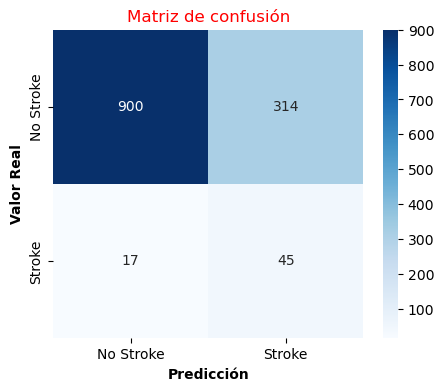

Accuracy: 0.74 
F1: 0.21 
Recall: 0.73 
Precision: 0.13


In [92]:
modelo_knn = KNeighborsClassifier(n_neighbors = 50)
Aplicar_modelo(model = modelo_knn, X_train = X_train_b_scaled, y_train = y_train_b, X_test = X_test_scaled, y_test = y_test)

### Random Forest

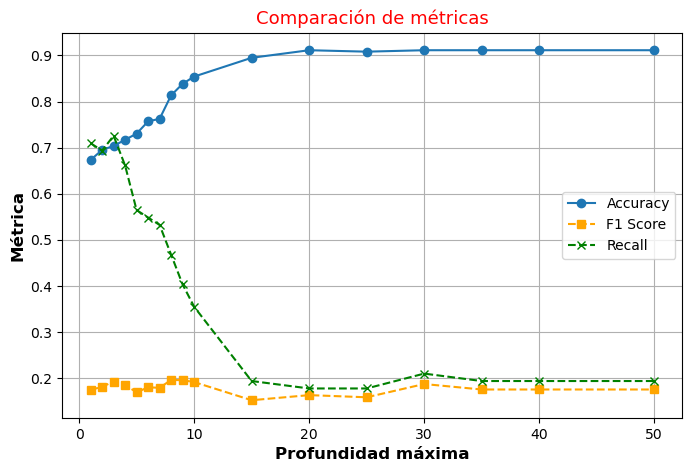

In [94]:
accuracy_list = []
f1_list = []
recall_list = []
n_depth = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,50]

for n in n_depth:
    modelo = RandomForestClassifier(max_depth = n, random_state = 34)
    modelo.fit(X_train_b_scaled, y_train_b)
    y_pred = modelo.predict(X_test_scaled)
    matriz_confusion = confusion_matrix(y_test, y_pred)
    accuracy_list.append(accuracy_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

plt.figure(figsize=(8, 5))          
plt.plot(n_depth, accuracy_list, 'o-', label='Accuracy')
plt.plot(n_depth, f1_list, 's--', label='F1 Score', color='orange')
plt.plot(n_depth, recall_list, 'x--', label='Recall', color='green')
plt.grid(True)
plt.xlabel("Profundidad máxima", fontweight="black", fontsize=12)
plt.ylabel("Métrica", fontweight="black", fontsize=12)
plt.title("Comparación de métricas", fontsize=13, color="r")
plt.legend()
plt.show()

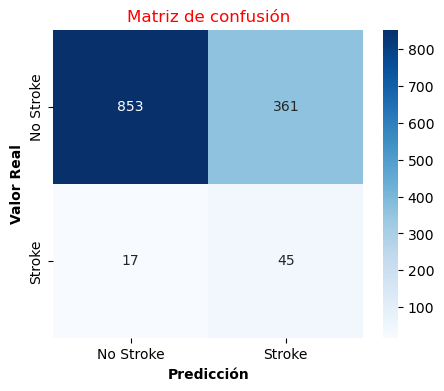

Accuracy: 0.7 
F1: 0.19 
Recall: 0.73 
Precision: 0.11


In [95]:
modelo_rf = RandomForestClassifier(max_depth = 3, random_state = 34)
Aplicar_modelo(model = modelo_rf, X_train = X_train_b_scaled, y_train = y_train_b, X_test = X_test_scaled, y_test = y_test)

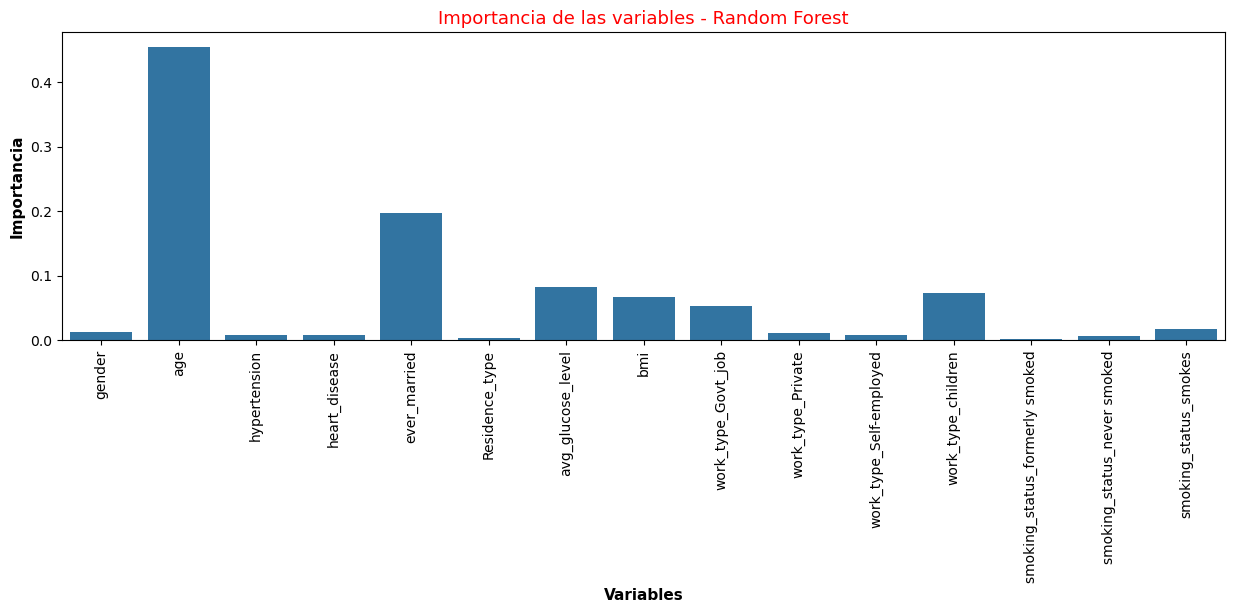

In [175]:
plt.figure(figsize=(15, 4))
sns.barplot(x = X_train_b_scaled.columns, y = modelo_rf.feature_importances_)
plt.ylabel("Importancia", fontweight = "black", fontsize = 11)
plt.xlabel("Variables", fontweight = "black", fontsize = 11)
plt.title("Importancia de las variables - Random Forest", fontsize = 13, color = "r")
plt.xticks(rotation = 90)
plt.show()